# Opdracht 1

In [22]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import os

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA, NMF
from sklearn.datasets import make_blobs
from IPython.display import Audio, display
from pathlib import Path

#DataFrame maken
df = pd.read_csv('labels_new.csv')

In [23]:
#Information df
display(df.head())
print("aantal samples:",len(df))
print("aantal genres:",df['genre'].nunique())
display(df['genre'].value_counts())

,filename,genre
0,m00248.wav,metal
1,m00230.wav,country
2,m00637.wav,hiphop
3,m00627.wav,metal
4,m00138.wav,reggae


aantal samples: 50
aantal genres: 10


genre
metal        5
country      5
hiphop       5
reggae       5
classical    5
jazz         5
rock         5
pop          5
blues        5
disco        5
Name: count, dtype: int64

In [24]:
#Labeled and unlabeled directions and files
labeled_audio_dir = Path('labeled')
labeled_audio_files = os.listdir(labeled_audio_dir)

unlabeled_audio_dir = Path('unlabeled')
unlabeled_audio_files = os.listdir(unlabeled_audio_dir)
df_unlabeled = pd.DataFrame(os.listdir(unlabeled_audio_dir))

In [25]:
#https://librosa.org/doc/latest/feature.html

class LibrosaFeatures:

    def __init__(self, audio_dir):
        self.audio_dir = Path(audio_dir)
        self.features_list = []

    def features(self, audio_files):
        self.features_list = [] 
        for file in audio_files:
            file_path = self.audio_dir / file
            features = self.process_file(file_path, file)
            self.features_list.append(features)
        return pd.DataFrame(self.features_list)

    def process_file(self, file_path, file):
        y, sr = librosa.load(file_path)

        features = {
            'filename': file,
            'spectral_bandwidth': np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
            'spectral_bandwidth_std': np.std(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
            'spectral_centroid': np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
            'spectral_centroid_std': np.std(librosa.feature.spectral_centroid(y=y, sr=sr)),
            'zero_crossing_rate': np.mean(librosa.feature.zero_crossing_rate(y)),
            'zero_crossing_rate_std': np.std(librosa.feature.zero_crossing_rate(y)),
            'rms': np.mean(librosa.feature.rms(y=y)),
            'rms_std': np.std(librosa.feature.rms(y=y)),
            'rolloff': np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)),
            'flatness': np.mean(librosa.feature.spectral_flatness(y=y)),
            'tempo': librosa.beat.tempo(y=y, sr=sr)[0]}

        #Rhythm
        rhythm = librosa.onset.onset_strength(y=y, sr=sr)
        tempo, beats = librosa.beat.beat_track(onset_envelope=rhythm, sr=sr)

        features.update({
            'onset_strength_mean': np.mean(rhythm),
            'onset_strength_std': np.std(rhythm),
            'beat_strength': np.mean(librosa.util.normalize(rhythm)[beats]) if len(beats) > 0 else 0
        })

        #Harmonic
        harmonic, percussive = librosa.effects.hpss(y)
        features.update({
            'harmonic_ratio': np.mean(np.abs(harmonic)) / (np.mean(np.abs(percussive)) + 1e-8),
            'percussive_ratio': np.mean(np.abs(percussive)) / (np.mean(np.abs(harmonic)) + 1e-8)
        })

        #MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            features[f'mfcc_{i+1}'] = np.mean(mfcc[i])
            features[f'mfcc_{i+1}_std'] = np.std(mfcc[i])

        #Chromagram
        chromagram = librosa.feature.chroma_stft(y=y, sr=sr)
        for i in range(12):
            features[f'chroma_{i+1}'] = np.mean(chromagram[i])
            features[f'chroma_{i+1}_std'] = np.std(chromagram[i])

        #Tempogram
        tempogram = librosa.feature.tempogram(y=y, sr=sr)
        features.update({
            'tempogram_ratio': np.mean(tempogram) / (np.std(tempogram) + 1e-8),
            'tempogram_std': np.std(tempogram)
        })

        return features

    def merge(self, labels_df):
        features_df = pd.DataFrame(self.features_list)
        return pd.merge(features_df, labels_df, on='filename')

#Remove warnings
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    pull = LibrosaFeatures(labeled_audio_dir)
    df_features = pull.features(labeled_audio_files)
    df_audio_features = pull.merge(df)

#Columns check
df_audio_features.columns

Index(['filename', 'spectral_bandwidth', 'spectral_bandwidth_std',
       'spectral_centroid', 'spectral_centroid_std', 'zero_crossing_rate',
       'zero_crossing_rate_std', 'rms', 'rms_std', 'rolloff', 'flatness',
       'tempo', 'onset_strength_mean', 'onset_strength_std', 'beat_strength',
       'harmonic_ratio', 'percussive_ratio', 'mfcc_1', 'mfcc_1_std', 'mfcc_2',
       'mfcc_2_std', 'mfcc_3', 'mfcc_3_std', 'mfcc_4', 'mfcc_4_std', 'mfcc_5',
       'mfcc_5_std', 'mfcc_6', 'mfcc_6_std', 'mfcc_7', 'mfcc_7_std', 'mfcc_8',
       'mfcc_8_std', 'mfcc_9', 'mfcc_9_std', 'mfcc_10', 'mfcc_10_std',
       'mfcc_11', 'mfcc_11_std', 'mfcc_12', 'mfcc_12_std', 'mfcc_13',
       'mfcc_13_std', 'chroma_1', 'chroma_1_std', 'chroma_2', 'chroma_2_std',
       'chroma_3', 'chroma_3_std', 'chroma_4', 'chroma_4_std', 'chroma_5',
       'chroma_5_std', 'chroma_6', 'chroma_6_std', 'chroma_7', 'chroma_7_std',
       'chroma_8', 'chroma_8_std', 'chroma_9', 'chroma_9_std', 'chroma_10',
       'chroma_10_st

Ik heb geprobeerd met de nieuwe code te doen maar dat lukt niet dan blijf ik een error krijgen. Er gaat waarschijnlijk iets fout in de pip install van mijn laptop maar dat is dan maar zo. Ik heb de warnings laten removen.

# Opdracht 2

Welke DataFrames hebben we nu allemaal? Hiermee gaan we werken om de clusters te maken en het beste model te vinden om de hoogste accuracy op kaggle te voorspellen.

In [26]:
#Labeled
display(df.head())
#Unlabeled
display(df_unlabeled.head())
#Audio features
display(df_audio_features.head())

,filename,genre
0,m00248.wav,metal
1,m00230.wav,country
2,m00637.wav,hiphop
3,m00627.wav,metal
4,m00138.wav,reggae


,0
0,m00003.wav
1,m00012.wav
2,m00013.wav
3,m00043.wav
4,m00044.wav


,filename,spectral_bandwidth,spectral_bandwidth_std,spectral_centroid,spectral_centroid_std,zero_crossing_rate,zero_crossing_rate_std,rms,rms_std,rolloff,...,chroma_9_std,chroma_10,chroma_10_std,chroma_11,chroma_11_std,chroma_12,chroma_12_std,tempogram_ratio,tempogram_std,genre
0,m00002.wav,1920.270843,352.469828,1451.862124,428.935223,0.051224,0.025074,0.050480,0.027131,3047.431199,...,0.377096,0.287583,0.328681,0.224478,0.326612,0.185700,0.306980,0.869013,0.200426,jazz
1,m00039.wav,2019.300256,442.196748,1811.410394,809.772584,0.072150,0.051697,0.123665,0.053056,3854.851374,...,0.223918,0.297682,0.275615,0.422818,0.337206,0.401892,0.297101,0.747660,0.139721,reggae
2,m00041.wav,2992.010638,346.836989,3110.898196,779.418889,0.152857,0.068744,0.198322,0.077807,6744.988603,...,0.323897,0.332073,0.237859,0.445475,0.354692,0.293710,0.220588,0.802305,0.187328,pop
3,m00072.wav,2709.897108,360.419232,2624.814629,585.287392,0.120217,0.038883,0.142927,0.062914,5605.777240,...,0.329127,0.282717,0.175517,0.376277,0.294601,0.277690,0.236222,0.806668,0.193607,disco
4,m00096.wav,2485.524548,368.525304,2549.269757,695.078336,0.115834,0.050427,0.184340,0.098477,5583.144894,...,0.298731,0.244928,0.281050,0.239062,0.275884,0.318006,0.307679,0.729187,0.165431,disco


---

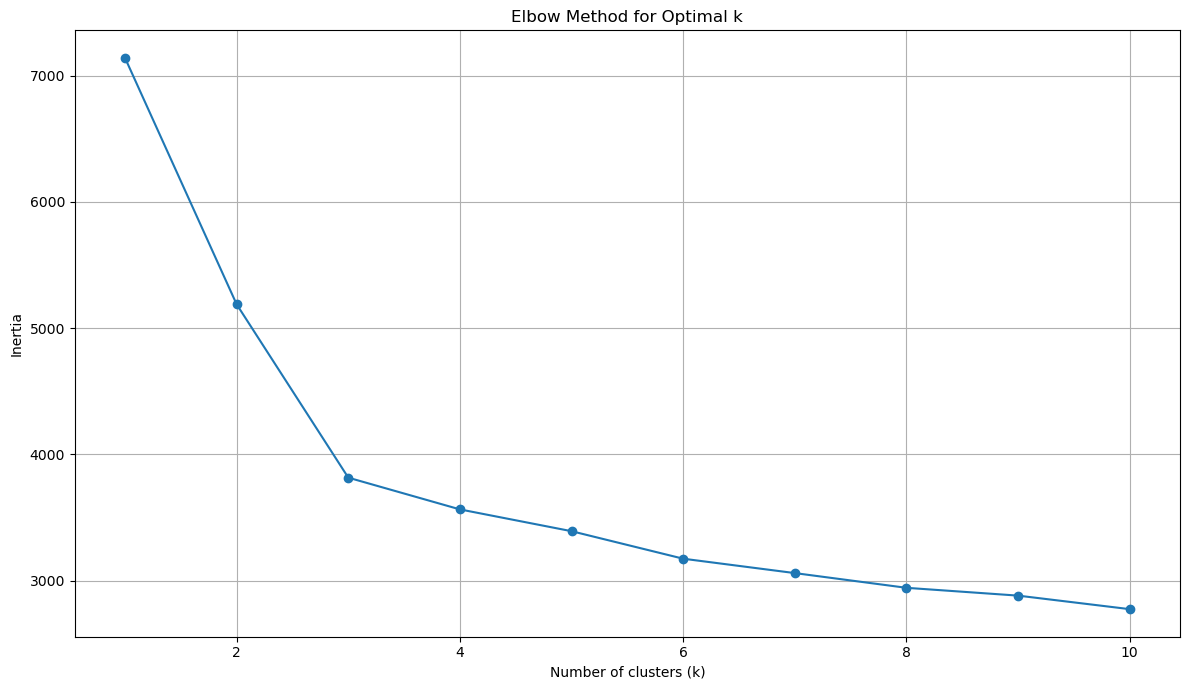

In [27]:
#Remove warnings, hierdoor meer clean output.
os.environ["OMP_NUM_THREADS"] = "1"

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)

warnings.filterwarnings(
    "ignore",
    message="librosa.beat.tempo"
)

unlabeled_features = LibrosaFeatures(unlabeled_audio_dir).features(unlabeled_audio_files)
X = unlabeled_features.drop("filename", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Elbow Method
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

#Plotting
plt.figure(figsize=(12, 7))
plt.plot(K, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.tight_layout()
plt.show()

Drie clusters is optimaal voor gebruik.

3 clusters - 0.98 Kaggle score

In [28]:
#KMeans
kmeans = KMeans(n_clusters = 3, random_state=42)
unlabeled_features["clusters"] = kmeans.fit_predict(X_scaled)
df_unlabeled["clusters"] = kmeans.labels_
genres = {
    0: "pop",
    1: "metal",
    2: "classical"
}
df_unlabeled["genre"] = df_unlabeled["clusters"].map(genres)

#Submission
df_unlabeled.rename(columns={0: 'filename'}, inplace=True)
df_unlabeled[['filename', 'genre']].to_csv(
    'submission_01.csv',
    index=False
)

4 clusters - 0.66 Kaggle score

In [31]:
#KMeans
kmeans = KMeans(n_clusters = 4, random_state=42)
unlabeled_features["clusters"] = kmeans.fit_predict(X_scaled)
df_unlabeled["clusters"] = kmeans.labels_
genres = {
    0: "pop",
    1: "metal",
    2: "classical"
}
df_unlabeled["genre"] = df_unlabeled["clusters"].map(genres)

#Submission
df_unlabeled.rename(columns={0: 'filename'}, inplace=True)
df_unlabeled[['filename', 'genre']].to_csv(
    'submission_02.csv',
    index=False
)

10 clusters - 0.13 Kaggle score

In [32]:
#KMeans
kmeans = KMeans(n_clusters = 10, random_state=42)
unlabeled_features["clusters"] = kmeans.fit_predict(X_scaled)
df_unlabeled["clusters"] = kmeans.labels_
genres = {
    0: "pop",
    1: "metal",
    2: "classical"
}
df_unlabeled["genre"] = df_unlabeled["clusters"].map(genres)

#Submission
df_unlabeled.rename(columns={0: 'filename'}, inplace=True)
df_unlabeled[['filename', 'genre']].to_csv(
    'submission_03.csv',
    index=False
)